### Preparations: DataLoaders & Evaluators

all utility functions written below are packed into @utils.py

In [106]:
import torch
import torchvision
from torch import nn
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

In [89]:
trans = transforms.ToTensor()
mnist_data = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="./data", train=False, transform=trans, download=True)
len(mnist_data), len(mnist_test)

(60000, 10000)

In [90]:
batch_size = 64
dataloader = data.DataLoader(mnist_data, batch_size=batch_size, shuffle=True)
testloader = data.DataLoader(mnist_test, batch_size=batch_size, shuffle=True)
feature, label = next(iter(dataloader))
feature.shape, label.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [91]:
class Accumulator:
    def __init__(self, n):
        self.data = [0.0] * n
    
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    
    def reset(self):
        self.data = [0.0] * len(self.data)
    
    def __getitem__(self, key):
        return self.data[key]

In [92]:
def accuracy(y_hat, y):
    y_hat = y_hat.argmax(axis=1)
    cmp = (y_hat == y)
    return cmp.float().sum().item()

def evaluator(net, test_iter):
    if isinstance(net, nn.Module):
        net.eval()
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in test_iter:
            y_hat = net(X)
            acc = accuracy(y_hat, y)
            metric.add(acc, y.numel())
    return metric[0] / metric[1]

now the dataloaders are ready. following is the **softmax regression**

### Model

In [93]:
net = nn.Sequential(
    nn.Flatten(), 
    nn.Linear(in_features=784, out_features=10))
for name, param in net[1].named_parameters():
    print(name, param.shape)

weight torch.Size([10, 784])
bias torch.Size([10])


In [94]:
def init_weight(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
        nn.init.zeros_(m.bias)
net.apply(init_weight)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

### Loss Function

In [95]:
loss_function = nn.CrossEntropyLoss()

### Optimizer

In [96]:
learning_rate = 0.01
optimizer = torch.optim.SGD(
    params=net.parameters(),
    lr=learning_rate)

test if the model was correct

the ans should be around 0.1

In [97]:
evaluator(net, testloader)

0.1398

### Train

In [103]:
def train_epoch(model, data_iter, loss_function, optimizer):
    """
    return: train accuracy (percentage)
    """
    if isinstance(model, nn.Module):
        model.train()
    metric = Accumulator(2)
    for X, y in data_iter:
        y_hat = model(X)
        loss = loss_function(y_hat, y)
        
        optimizer.zero_grad()
        loss.mean().backward()
        optimizer.step()
        metric.add(accuracy(y_hat, y), y.numel())
    return metric[0] / metric[1]

In [104]:
def train(model, data_iter, loss_function, optimizer, epochs, test_iter):
    train_acc, test_acc = [], []
    for _ in range(epochs):
        train_metric = train_epoch(model, data_iter, loss_function, optimizer)
        train_acc.append(train_metric)
        with torch.no_grad():
            test_metric = evaluator(model, test_iter)
            test_acc.append(test_metric)
    return train_acc, test_acc    

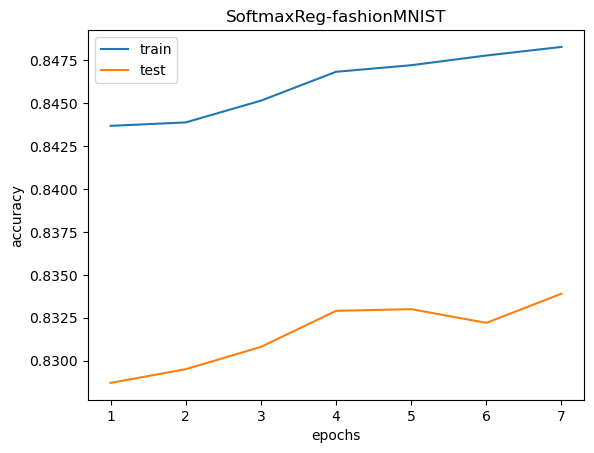

In [108]:
train_acc, test_acc = train(net, dataloader, loss_function, optimizer, 7, testloader)
fig, ax = plt.subplots()
ax.set_title("SoftmaxReg-fashionMNIST")
ax.set_xlabel("epochs")
ax.set_ylabel("accuracy")
ax.plot(range(1, 8), train_acc, label="train")
ax.plot(range(1, 8), test_acc, label="test")
ax.legend()
plt.show()